### Introduction to Atomate2 Workflows

 Atomate2 provides a modular, extensible framework built on top of several core packages—Jobflow, Custodian, Fireworks, Emmet, Maggma and Pymatgen—that together streamline high‐throughput computational materials science.

![Atomate2 workflow schema](atomate2_schema.png)
[Image source](https://members.cecam.org/storage/presentation/atomate2_intro-1742285569.pdf) by Alex Ganose

We will discuss some concepts from most relevant user-facing libraries. 

### Workflow Management with Jobflow and Fireworks

- **Jobflow**  
  Jobflow defines high‐level workflow abstractions. It defines “jobs” (atomic tasks, such as a static DFT calculation) and “flows” (collections of jobs connected by dependencies).
  
   By encapsulating each step of our calculation—structure preparation, DFT relaxation, phonon analysis—as a Jobflow job, we can automatically chain them together and handle branching logic and dynamic numbers of jobs (e.g., depending on the symmetry of a structure dynamically generate a number of calculations of structures with displaced atoms for a phonon workflow).
   
Below you can find the most basic job example that adds two numbers.

In [7]:
# adapted from jobflow tutorial https://materialsproject.github.io/jobflow/tutorials/1-quickstart.html
import os
os.environ["JOBFLOW_CONFIG_FILE"] = "../jobflow.yaml"
from jobflow import SETTINGS, Flow, job, run_locally, JobStore

store = SETTINGS.JOB_STORE
store.connect()

@job
def add(a, b):
    return a + b


add_first = add(1, 2)
add_second = add(add_first.output, 3)
flow = Flow([add_first, add_second])

Running add(1, 2) returns a job object. You can use the reference to that output in a second job.

The job add_second will only be able to run after add_first has been successfully executed.

A Flow is a collection of other jobs or Flow objects. The order in the list [add_first, add_second] does not matter, as the execution order is determined by their dependencies. In this case, add_second requires the output of add_first as an input. This dependency can be visualized using:

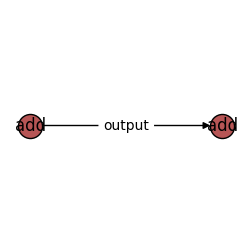

In [8]:
flow.draw_graph(figsize=(3, 3)).show()

So far the additions have not been executed. To run the flow, we can use the `run_locally` function:

In [9]:
from maggma.stores import MemoryStore
job_store = JobStore(
    MemoryStore(),
    additional_stores={"data": MemoryStore()},
)
responses = run_locally(flow, store=job_store)
print("Final result:", responses[add_first.uuid][1].output)

2026-03-04 11:23:02,525 INFO Started executing jobs locally
2026-03-04 11:23:02,526 INFO Starting job - add (3f2c0633-8b46-406d-950d-3041340cbbbe)
2026-03-04 11:23:02,527 INFO Finished job - add (3f2c0633-8b46-406d-950d-3041340cbbbe)
2026-03-04 11:23:02,528 INFO Starting job - add (2add8c37-db25-4edd-93d2-f3332a0ba4cb)
2026-03-04 11:23:02,528 INFO Finished job - add (2add8c37-db25-4edd-93d2-f3332a0ba4cb)
2026-03-04 11:23:02,528 INFO Finished executing jobs locally
Final result: 3
2026-03-04 11:23:02,526 INFO Starting job - add (3f2c0633-8b46-406d-950d-3041340cbbbe)
2026-03-04 11:23:02,527 INFO Finished job - add (3f2c0633-8b46-406d-950d-3041340cbbbe)
2026-03-04 11:23:02,528 INFO Starting job - add (2add8c37-db25-4edd-93d2-f3332a0ba4cb)
2026-03-04 11:23:02,528 INFO Finished job - add (2add8c37-db25-4edd-93d2-f3332a0ba4cb)
2026-03-04 11:23:02,528 INFO Finished executing jobs locally
Final result: 3


The results of the jobs are stored in the JobStore, a MongoDB database. For testing purposes we could also use `MemoryStore` that only persists in the current process. (larger documents (BSON limit of 16MB) can be stored in a GridFS or AWS S3 store. The different stores are defined in the maggma package. The database was already set up for the tutorial, and you were provided with the yaml files that have the credentials to access the database. 
While we commonly create jobs and workflows on our workstations we usually run them on HPC resources. For this purpose we will use `fireworks`.

[**Fireworks**](https://materialsproject.github.io/fireworks/)  

<img src="fireworks_schema.png" alt="Fireworks" style="width:80%;"/>


  Fireworks serves as an interface to the HPC resources we are using. It is responsible for:


  1. **Queuing & Scheduling**: Dispatching jobs onto HPC clusters. Managing a constant number of jobs in queue etc.    
  2. **Dependency Resolution**: E.g. ensuring that a phonon calculation only starts after its parent relaxation job has successfully completed.

  You will notice that the dependency resolution is already included in jobflow. Fireworks precurses the development of jobflow and right now [Jobflow Remote](https://matgenix.github.io/jobflow-remote/index.html#) is being developed as an alternative to Fireworks. However as it is still in beta, we will use Fireworks in this tutorial.
  
  Fireworks defines `firework` and `workflow` classes that correspond to the `job` and `Flow`. `flow_to_workflow` and `job_to_firework` allow for automatic conversion between the two.

In [10]:
from jobflow.managers.fireworks import flow_to_workflow
from fireworks import LaunchPad

add_first = add(1, 2, name="add_first")
add_second = add(add_first.output, 3, name="add_second")
flow = Flow([add_first, add_second])

wf = flow_to_workflow(flow)

lpad = LaunchPad.from_file("../my_launchpad.yaml")
lpad.add_wf(wf)

2026-03-04 11:23:05,421 INFO Added a workflow. id_map: {-4: 801, -3: 802}


{-4: 801, -3: 802}

By adding the workflow to the LaunchPad, it will be submitted to the FireWorks MongoDB for execution. You can now run
`lpad -l ../my_launchpad.yaml get_fws` in your terminal to see the status of all FireWorks jobs. You can also use `lpad -l ../my_launchpad.yaml webgui` as a graphical user interface.

You will see that each job was assigned a unique fireworks id and that the status of one job shows **READY** while the second job is waiting for the result of the first one as we expect.

Test what happens if you try to run your job on kuma with the command
`rlaunch singleshot`